Kích thước tập Train: 8000
Kích thước tập Test: 2000

 PHẦN 1: BÀI TOÁN PHÂN LỚP SENTIMENT 
Đang huấn luyện mô hình NB...
F1-macro Score: 0.8123
Đang huấn luyện mô hình LOGREG...
F1-macro Score: 0.8344
Đang huấn luyện mô hình RF...
F1-macro Score: 0.7925


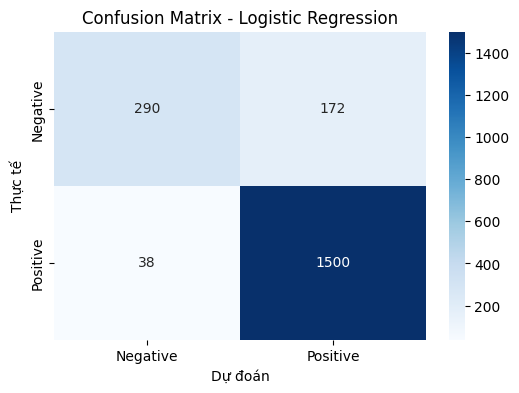


 PHẦN 2: BÀI TOÁN HỒI QUY DỰ ĐOÁN RATING 
Đang huấn luyện mô hình hồi quy RIDGE...
MAE: 0.9744 | RMSE: 1.2370
Đang huấn luyện mô hình hồi quy RF...
MAE: 0.9423 | RMSE: 1.2058


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import sys
import os

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.append(os.getcwd())

from src.models.supervised import train_evaluate_classifier
from src.models.regression import train_evaluate_regressor

# 1. Tải dữ liệu đã có đặc trưng
df = pd.read_csv("data/processed/featured_reviews.csv")
# Loại bỏ các dòng bị NaN ở rating (nếu còn sót)
df = df.dropna(subset=['reviews.rating', 'Cleaned_Review']).copy()

# Tạo nhãn Sentiment cho bài toán Phân lớp: >=4 là Khen (1), <4 là Phàn nàn (0)
df['Sentiment'] = df['reviews.rating'].apply(lambda x: 1 if float(x) >= 4 else 0)

# Chia tập Train/Test (Tỷ lệ 80/20, seed=42 để có thể chạy lại y hệt)
X = df['Cleaned_Review']
y_class = df['Sentiment']
y_reg = df['reviews.rating']

X_train, X_test, y_train_cls, y_test_cls = train_test_split(X, y_class, test_size=0.2, random_state=42, stratify=y_class)
_, _, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

print("Kích thước tập Train:", X_train.shape[0])
print("Kích thước tập Test:", X_test.shape[0])

print("\n" + "="*40 + "\n PHẦN 1: BÀI TOÁN PHÂN LỚP SENTIMENT \n" + "="*40)
# Chạy 2 Baseline và 1 Cải tiến
model_nb, y_pred_nb, f1_nb = train_evaluate_classifier(X_train, X_test, y_train_cls, y_test_cls, 'nb')
model_logreg, y_pred_logreg, f1_logreg = train_evaluate_classifier(X_train, X_test, y_train_cls, y_test_cls, 'logreg')
model_rf_cls, y_pred_rf, f1_rf = train_evaluate_classifier(X_train, X_test, y_train_cls, y_test_cls, 'rf')

# Vẽ Confusion Matrix cho mô hình tốt nhất (thường là Logistic Regression hoặc RF)
cm = confusion_matrix(y_test_cls, y_pred_logreg)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

print("\n" + "="*40 + "\n PHẦN 2: BÀI TOÁN HỒI QUY DỰ ĐOÁN RATING \n" + "="*40)
# Chạy Baseline và Mô hình mạnh
model_ridge, y_pred_ridge, mae_ridge, rmse_ridge = train_evaluate_regressor(X_train, X_test, y_train_reg, y_test_reg, 'ridge')
model_rf_reg, y_pred_rf_reg, mae_rf, rmse_rf = train_evaluate_regressor(X_train, X_test, y_train_reg, y_test_reg, 'rf')